# Tuning - XGBoost Regressor para limiar de reposicao

Este notebook desenvolve o XGBoost Regressor, recomendado como segunda opcao para o limiar de reposicao por combinar boa capacidade nao linear com regularizacao forte. Nenhum `.pkl` e salvo localmente; todos os artefatos seguem para o MLflow.


## Estrategia

Usamos `TimeSeriesSplit` pelo mesmo motivo do Random Forest: o problema e temporal e nao deve misturar futuro no treino de folds anteriores. `Stratified K-Fold` nao se aplica ao alvo continuo, `Leave-One-Out` e caro e instavel, e holdout isolado nao mede variancia entre folds.

O tuning usa `RandomizedSearchCV` em uma configuracao leve, mais barata que Grid Search para XGBoost porque o espaco inclui profundidade, taxa de aprendizado, subsampling e regularizacoes L1/L2.


In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
UTILS_DIR = next(
    (candidate / "utils" for candidate in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents] if (candidate / "utils").is_dir()),
    None,
)
if UTILS_DIR is None:
    raise RuntimeError("Nao encontrei ml/notebooks/utils. Execute o notebook dentro do repositorio Saltim.")
sys.path.insert(0, str(UTILS_DIR))

import pandas as pd

from regressor_tuning_common import (
    RegressorTuningConfig,
    WEIGHT_PROFILE_DESCRIPTIONS,
    run_regressor_tuning,
)

from xgboost import XGBRegressor


In [2]:
XGB_PARAM_DISTRIBUTIONS = {
    "model__n_estimators": [100, 180, 260],
    "model__max_depth": [2, 3, 4],
    "model__learning_rate": [0.03, 0.05, 0.08],
    "model__subsample": [0.85, 1.0],
    "model__colsample_bytree": [0.85, 1.0],
    "model__min_child_weight": [1, 3, 5],
    "model__gamma": [0.0, 0.10],
    "model__reg_alpha": [0.0, 0.10],
    "model__reg_lambda": [1.0, 2.0],
}

def xgb_model_factory() -> XGBRegressor:
    return XGBRegressor(
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method="hist",
        random_state=42,
        n_jobs=2,
    )

def xgb_baseline_factory() -> XGBRegressor:
    return XGBRegressor(
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method="hist",
        n_estimators=180,
        max_depth=3,
        learning_rate=0.05,
        random_state=42,
        n_jobs=2,
    )

config = RegressorTuningConfig(
    notebook_id="06_xgboost_regressor_threshold_tuning",
    family="Arvores",
    model_name="XGBoost Regressor",
    model_factory=xgb_model_factory,
    baseline_factory=xgb_baseline_factory,
    param_distributions=XGB_PARAM_DISTRIBUTIONS,
    n_iter=8,
    cv_splits=3,
    random_state=42,
    n_jobs=1,
    use_full_dataset=True,
    weight_profiles=("uniform", "alert_focus"),
)

search_space = pd.DataFrame(
    [{"parametro": key, "valores": values} for key, values in XGB_PARAM_DISTRIBUTIONS.items()]
)
weight_profiles = pd.DataFrame(
    [
        {"perfil": key, "descricao": WEIGHT_PROFILE_DESCRIPTIONS[key]}
        for key in config.weight_profiles
    ]
)

display(search_space)
display(weight_profiles)


,parametro,valores
0,model__n_estimators,"[100, 180, 260]"
1,model__max_depth,"[2, 3, 4]"
2,model__learning_rate,"[0.03, 0.05, 0.08]"
3,model__subsample,"[0.85, 1.0]"
4,model__colsample_bytree,"[0.85, 1.0]"
5,model__min_child_weight,"[1, 3, 5]"
6,model__gamma,"[0.0, 0.1]"
7,model__reg_alpha,"[0.0, 0.1]"
8,model__reg_lambda,"[1.0, 2.0]"


,perfil,descricao
0,uniform,Peso 1 para todas as amostras; usado como cont...
1,alert_focus,Aumenta peso de observacoes em Alerta de compr...


## Execucao do tuning

Esta etapa registra no MLflow: baseline, candidatos de Random Search, resultados por fold, melhor combinacao de hiperparametros, modelo campeao, predicoes e graficos.


2026/06/01 21:25:47 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/06/01 21:25:47 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.
2026/06/01 21:25:50 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/sophia/www/cesar/6/projetos/Projetos-6-Saltim/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/lat

🏃 View run XGBoost Regressor baseline at: http://localhost:5000/#/experiments/18/runs/37c8ba52ee5149fe9686f3b4c95210eb
🧪 View experiment at: http://localhost:5000/#/experiments/18


2026/06/01 21:27:42 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/sophia/www/cesar/6/projetos/Projetos-6-Saltim/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


Fitting 3 folds for each of 8 candidates, totalling 24 fits


2026/06/01 21:29:29 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/sophia/www/cesar/6/projetos/Projetos-6-Saltim/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/06/01 21:29:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format require

...

🏃 View run XGBoost Regressor candidate alert_focus #6 at: http://localhost:5000/#/experiments/18/runs/9728ead0b32245bfa80b75d9e5dd45ad
🧪 View experiment at: http://localhost:5000/#/experiments/18


2026/06/01 21:32:24 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/06/01 21:32:24 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.


🏃 View run XGBoost Regressor candidate alert_focus #5 at: http://localhost:5000/#/experiments/18/runs/538d936b0e8347008f2f84e6d507d750
🧪 View experiment at: http://localhost:5000/#/experiments/18
🏃 View run XGBoost Regressor candidate alert_focus #2 at: http://localhost:5000/#/experiments/18/runs/d3adc8d6b03742c79a946cd3a6f9882f
🧪 View experiment at: http://localhost:5000/#/experiments/18
🏃 View run XGBoost Regressor random search - alert_focus at: http://localhost:5000/#/experiments/18/runs/22077f14c519476a8393fa87b32eb5e2
🧪 View experiment at: http://localhost:5000/#/experiments/18


2026/06/01 21:32:37 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/sophia/www/cesar/6/projetos/Projetos-6-Saltim/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/06/01 21:32:45 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/sophi

🏃 View run XGBoost Regressor champion at: http://localhost:5000/#/experiments/18/runs/58db15b4b9364e6cb1bf7d9ebe65f922
🧪 View experiment at: http://localhost:5000/#/experiments/18
🏃 View run XGBoost Regressor tuning parent at: http://localhost:5000/#/experiments/18/runs/1b349a03e58b4818a48d65a2c1998d5b
🧪 View experiment at: http://localhost:5000/#/experiments/18


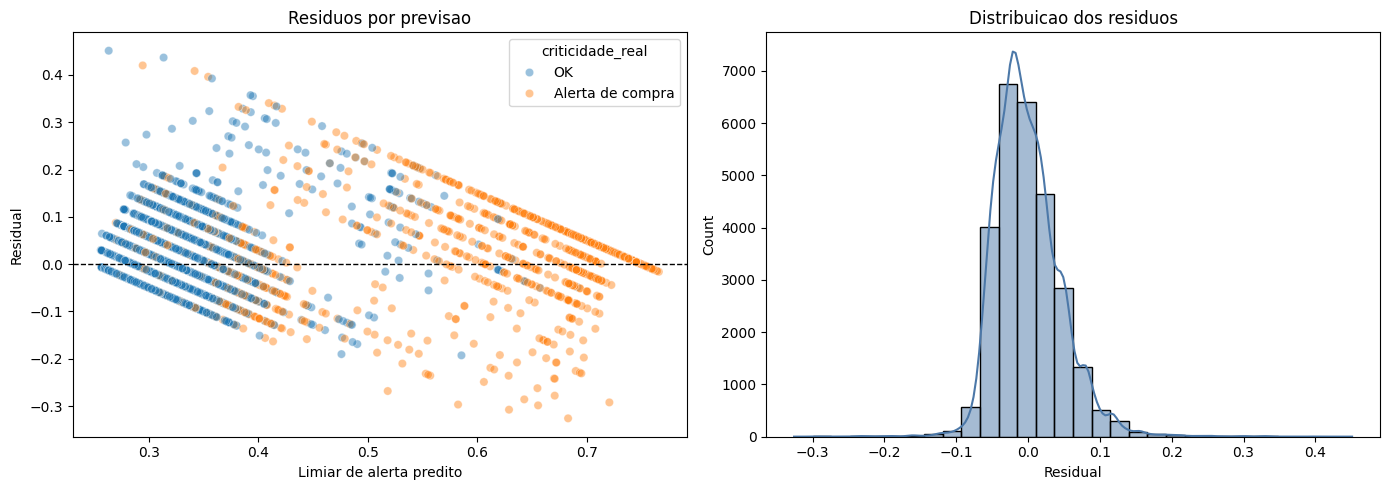

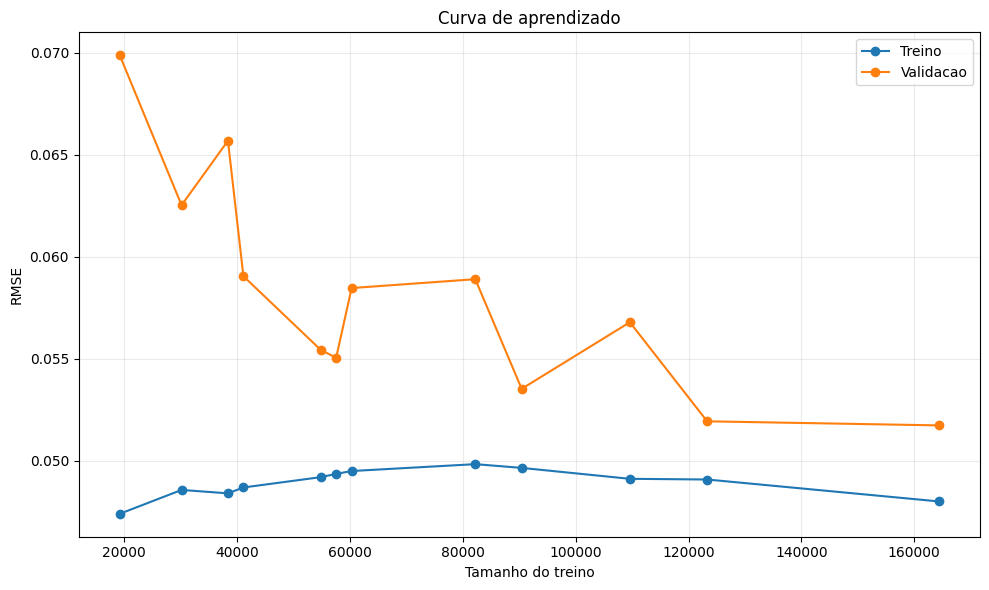

In [3]:
results = run_regressor_tuning(config)


## Resultados quantitativos

As tabelas abaixo permitem comparar baseline, top candidatos, variancia dos folds e performance final no holdout de teste.


In [4]:
display(results["baseline_summary"])
display(results["candidate_results"].head(15))
display(results["best_fold_metrics"])
display(results["final_metrics"].T)
print("Melhor perfil de peso:", results["best_weight_profile"])
print("Melhores hiperparametros:", results["best_params"])
print("Diagnostico:", results["fit_diagnosis"])


,baseline_cv_train_rmse_mean,baseline_cv_train_rmse_std,baseline_cv_validation_rmse_mean,baseline_cv_validation_rmse_std,baseline_cv_validation_rmse_var,baseline_cv_validation_mae_mean,baseline_cv_validation_r2_mean,baseline_test_rmse,baseline_test_mae,baseline_test_r2
0,0.053867,0.000324,0.058427,0.002779,0.000008,0.041894,0.680629,0.051662,0.038998,0.742945


,candidate_index,weight_profile,params_json,mean_train_rmse,std_train_rmse,mean_validation_rmse,std_validation_rmse,mean_train_mae,mean_validation_mae,mean_train_r2,...,rank_validation_rmse,subsample,reg_lambda,reg_alpha,n_estimators,min_child_weight,max_depth,learning_rate,gamma,colsample_bytree
0,1,uniform,"{""model__colsample_bytree"": 0.85, ""model__gamm...",0.048777,0.000543,0.054655,0.002136,0.036111,0.038990,0.767578,...,1,0.85,2.0,0.1,260,5,4,0.08,0.1,0.85
1,7,uniform,"{""model__colsample_bytree"": 0.85, ""model__gamm...",0.048972,0.000631,0.054814,0.002156,0.036228,0.039093,0.765681,...,2,0.85,2.0,0.1,180,1,4,0.08,0.1,0.85
2,0,uniform,"{""model__colsample_bytree"": 0.85, ""model__gamm...",0.049725,0.000118,0.055005,0.002031,0.036750,0.039386,0.758591,...,3,0.85,1.0,0.1,260,5,4,0.03,0.1,0.85
8,1,alert_focus,"{""model__colsample_bytree"": 0.85, ""model__gamm...",0.046312,0.000182,0.055720,0.003230,0.034720,0.039456,0.790607,...,1,0.85,2.0,0.1,260,5,4,0.08,0.1,0.85
9,7,alert_focus,"{""model__colsample_bytree"": 0.85, ""model__gamm...",0.046828,0.000278,0.056179,0.003213,0.035094,0.039663,0.785983,...,2,0.85,2.0,0.1,180,1,4,0.08,0.1,0.85
10,0,alert_focus,"{""model__colsample_bytree"": 0.85, ""model__gamm...",0.049623,0.000919,0.056783,0.002997,0.036909,0.040472,0.759749,...,3,0.85,1.0,0.1,260,5,4,0.03,0.1,0.85
3,4,uniform,"{""model__colsample_bytree"": 1.0, ""model__gamma...",0.056828,0.000262,0.059734,0.002796,0.041802,0.043129,0.684797,...,4,0.85,2.0,0.1,100,5,3,0.05,0.0,1.00
11,4,alert_focus,"{""model__colsample_bytree"": 1.0, ""model__gamma...",0.057417,0.000113,0.060404,0.002562,0.042458,0.043760,0.678198,...,4,0.85,2.0,0.1,100,5,3,0.05,0.0,1.00
12,3,alert_focus,"{""model__colsample_bytree"": 0.85, ""model__gamm...",0.059221,0.000342,0.062381,0.003041,0.044031,0.045709,0.657579,...,5,1.00,2.0,0.1,180,1,2,0.08,0.1,0.85
4,6,uniform,"{""model__colsample_bytree"": 0.85, ""model__gamm...",0.059124,0.000407,0.062569,0.003405,0.043198,0.045071,0.658820,...,5,0.85,2.0,0.0,180,3,2,0.08,0.0,0.85


,fold,weight_profile,train_rmse,validation_rmse,train_mae,validation_mae,train_r2,validation_r2
0,1,uniform,0.049200,0.055438,0.036656,0.040057,0.756846,0.704486
1,2,uniform,0.049120,0.056791,0.036144,0.039510,0.762999,0.719186
2,3,uniform,0.048011,0.051737,0.035533,0.037404,0.782887,0.737933


,0
notebook,06_xgboost_regressor_threshold_tuning
family,Arvores
stage,threshold_regression
model,XGBoost Regressor
accuracy,0.998165
balanced_accuracy,0.997126
f1_macro,0.996518
precision_macro,0.995913
recall_macro,0.997126
taxa_ok,0.843669


Melhor perfil de peso: uniform
Melhores hiperparametros: {'model__subsample': 0.85, 'model__reg_lambda': 2.0, 'model__reg_alpha': 0.1, 'model__n_estimators': 260, 'model__min_child_weight': 5, 'model__max_depth': 4, 'model__learning_rate': 0.08, 'model__gamma': 0.1, 'model__colsample_bytree': 0.85}
Diagnostico: {'fit_status': 'adequate', 'fit_explanation': 'Nao ha sinal forte de sobreajuste/subajuste nos criterios adotados.', 'train_validation_rmse_gap': 0.0069769143360132735, 'train_validation_rmse_gap_ratio': 0.14633226269109822, 'validation_rmse_std': 0.002136402306658548}


## Visualizacoes de ajuste

A curva de aprendizado compara erro de treino e validacao conforme adicionamos dados. A analise de residuos ajuda a encontrar vieses e erros extremos.


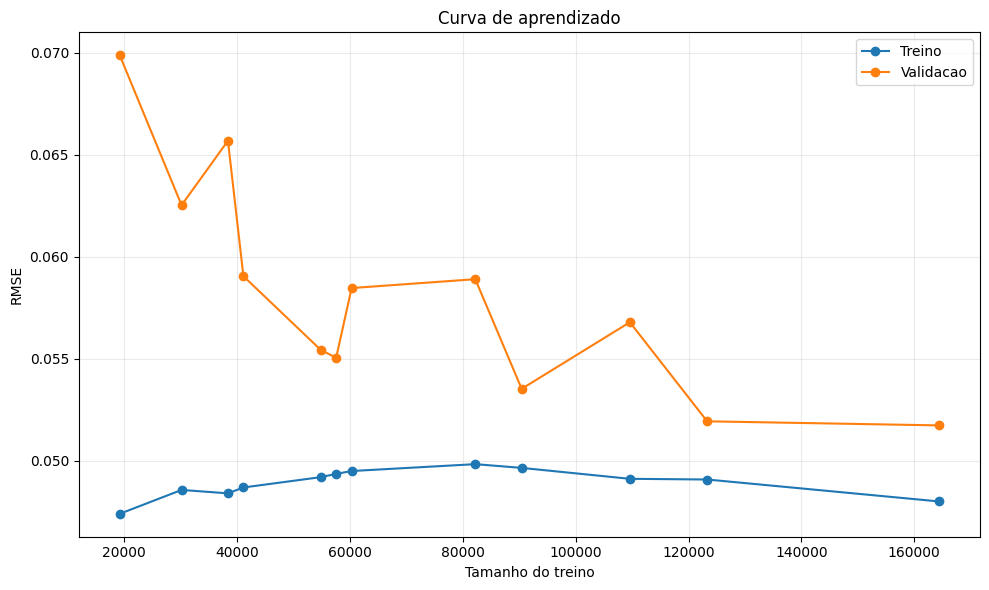

In [5]:
results["figures"]["learning_curve"]


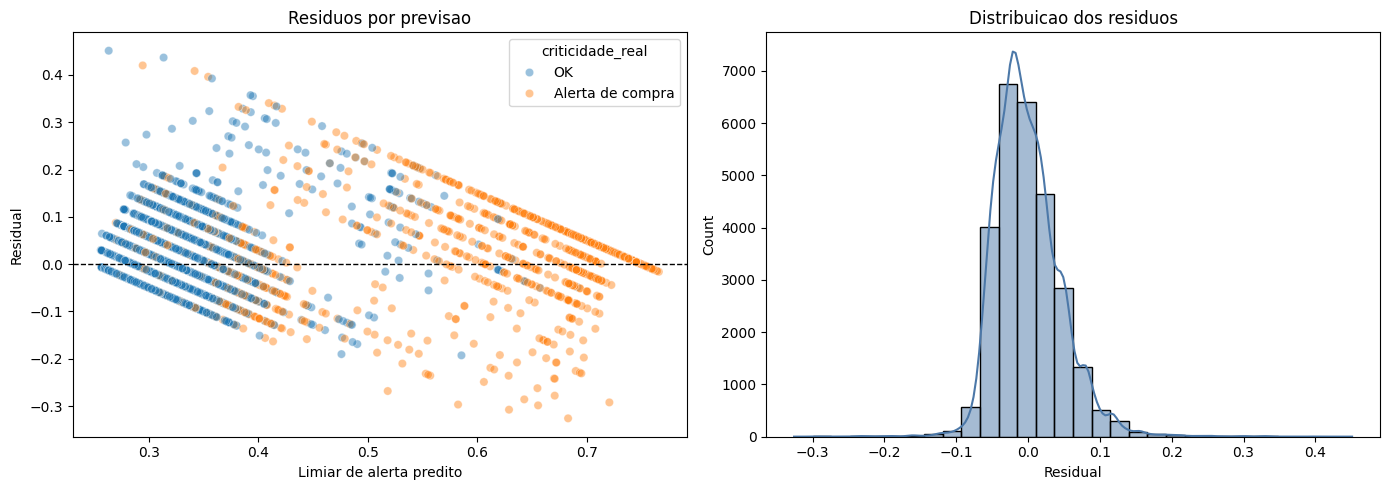

In [6]:
results["figures"]["residual_analysis"]


## MLflow

No MLflow, procure pelo experimento `notebooks/02_modelos_finais/06_xgboost_regressor_threshold_tuning/threshold_regression`. O run `champion` contem o modelo registrado; os runs de candidatos mostram os diferentes parametros e perfis de peso avaliados.
